In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [7]:
data = pd.read_csv("lagos_features.csv")
data.head(15)

,zone,avg_daily_rainfall_mm,max_daily_rainfall_mm,heavy_rain_days,rainy_season_avg_mm,elevation_m,waterway_feature_count,flood_label
0,Ajegunle,3.791396,159.3,71,5.409867,6.0,2,2
1,Ajeromi-Ifelodun,3.791396,159.3,71,5.409867,4.0,4,2
2,Apapa,3.404784,138.2,64,4.898123,5.0,4,1
3,Eti-Osa (VI/Lekki axis),3.404784,138.2,64,4.898123,6.0,60,2
4,Ikorodu,3.945341,123.4,78,5.797821,20.0,0,1
5,Ipaja,4.143235,90.7,78,6.037893,14.0,3,2
6,Iwaya,3.810746,148.3,76,5.457990,9.0,4,1
7,Ketu,3.993181,115.1,79,5.770036,22.0,7,2
8,Lekki Phase 1,3.404784,138.2,64,4.898123,5.0,21,2
9,Makoko,3.810746,148.3,76,5.457990,2.0,147,2


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   zone                    12 non-null     str    
 1   avg_daily_rainfall_mm   12 non-null     float64
 2   max_daily_rainfall_mm   12 non-null     float64
 3   heavy_rain_days         12 non-null     int64  
 4   rainy_season_avg_mm     12 non-null     float64
 5   elevation_m             12 non-null     float64
 6   waterway_feature_count  12 non-null     int64  
 7   flood_label             12 non-null     int64  
dtypes: float64(4), int64(3), str(1)
memory usage: 1006.0 bytes


In [12]:
data.describe()

,avg_daily_rainfall_mm,max_daily_rainfall_mm,heavy_rain_days,rainy_season_avg_mm,elevation_m,waterway_feature_count,flood_label,flood_binary
count,12.000000,12.000000,12.00000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,3.767107,136.150000,73.25000,5.412147,10.416667,21.250000,1.666667,0.666667
std,0.240782,19.197988,6.22495,0.365430,7.833011,43.011891,0.492366,0.492366
min,3.404784,90.700000,64.00000,4.898123,2.000000,0.000000,1.000000,0.000000
25%,3.694743,133.900000,69.25000,5.281931,5.000000,2.750000,1.000000,0.000000
50%,3.810746,138.200000,76.00000,5.454964,6.500000,4.000000,2.000000,1.000000
75%,3.875669,148.300000,78.25000,5.536002,15.500000,10.500000,2.000000,1.000000
max,4.143235,159.300000,79.00000,6.037893,25.000000,147.000000,2.000000,1.000000


In [13]:
# --- AUTOMATIC COLUMN DETECTION & FIX ---
# This block safely finds your target column and maps values (1 -> 0, 2 -> 1)
target_col = None
for col in data.columns:
    if "flood" in col.lower():
        target_col = col
        break

if target_col is None:
    raise KeyError("Could not find a column containing 'flood' in your dataset. Please check data.columns.")

# If the column isn't already named 'flood_binary', map it and create it
if target_col != "flood_binary":
    # If your column uses 1 and 2, this converts them to 0 and 1 respectively
    if set(data[target_col].unique()).issubset({1, 2}):
        data["flood_binary"] = data[target_col].map({1: 0, 2: 1})
    else:
        # If it's already 0 and 1 but named differently (e.g., 'flood_label')
        data["flood_binary"] = data[target_col]


# --- YOUR ORIGINAL FUNCTIONS (NOW SAFE) ---

def chart_1_rainfall_clusters():
    """Sorted rainfall by zone, same color = identical grid-cell value."""
    data_sorted = data.sort_values("avg_daily_rainfall_mm")
    colors = sns.color_palette("husl", data["avg_daily_rainfall_mm"].nunique())
    rain_to_color = {v: colors[i] for i, v in enumerate(sorted(data["avg_daily_rainfall_mm"].unique()))}
    bar_colors = [rain_to_color[v] for v in data_sorted["avg_daily_rainfall_mm"]]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(data_sorted["zone"], data_sorted["avg_daily_rainfall_mm"], color=bar_colors)
    ax.set_xlabel("Average daily rainfall (mm)")
    ax.set_title("Avg Daily Rainfall by Zone\n(same color = identical grid-cell value)")
    plt.tight_layout()
    plt.savefig("eda_1_rainfall_clusters.png", dpi=150)
    plt.close()


def chart_2_elevation_drainage_scatter():
    """Elevation vs. drainage density, colored by flood outcome."""
    fig, ax = plt.subplots(figsize=(9, 7))
    groups = [
        (1, "o", "#e74c3c", "Confirmed damage (2)"),
        (0, "s", "#3498db", "Flood-prone, no damage (1)"),
    ]
    for label, marker, color, name in groups:
        subset = data[data["flood_binary"] == label]
        ax.scatter(
            subset["elevation_m"], subset["waterway_feature_count"],
            s=180, marker=marker, color=color, label=name,
            edgecolor="black", linewidth=1, alpha=0.85,
        )
    for _, row in data.iterrows():
        ax.annotate(
            row["zone"], (row["elevation_m"], row["waterway_feature_count"]),
            fontsize=8, xytext=(5, 5), textcoords="offset points",
        )
    ax.set_xlabel("Elevation (m)")
    ax.set_ylabel("Waterway feature count")
    ax.set_title("Elevation vs. Drainage Density, by Flood Outcome")
    ax.legend()
    plt.tight_layout()
    plt.savefig("eda_2_elevation_drainage_scatter.png", dpi=150)
    plt.close()


def chart_3_correlation_heatmap():
    """Correlation matrix across all numeric features plus the target."""
    feature_cols = [
        "avg_daily_rainfall_mm", "max_daily_rainfall_mm", "heavy_rain_days",
        "rainy_season_avg_mm", "elevation_m", "waterway_feature_count", "flood_binary",
    ]
    # Filter only columns that actually exist in the DataFrame to prevent crashes
    existing_cols = [col for col in feature_cols if col in data.columns]
    corr = data[existing_cols].corr()

    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(
        corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
        square=True, ax=ax, cbar_kws={"label": "correlation"},
    )
    ax.set_title("Feature Correlation Matrix\n(flood_binary: 1=confirmed damage, 0=no confirmed damage)")
    plt.tight_layout()
    plt.savefig("eda_3_correlation_heatmap.png", dpi=150)
    plt.close()


def chart_4_boxplots_by_label():
    """Elevation and drainage distributions split by flood outcome."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    cols_titles = [
        ("elevation_m", "Elevation by Flood Outcome"),
        ("waterway_feature_count", "Drainage Features by Flood Outcome"),
    ]
    for ax, (col, title) in zip(axes, cols_titles):
        if col not in data.columns:
            continue
        data_to_plot = [data[data["flood_binary"] == 0][col], data[data["flood_binary"] == 1][col]]
        bp = ax.boxplot(
            data_to_plot,
            tick_labels=["No confirmed\ndamage (1)", "Confirmed\ndamage (2)"],
            patch_artist=True,
        )
        for patch, color in zip(bp["boxes"], ["#3498db", "#e74c3c"]):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        for i, d in enumerate(data_to_plot):
            x = np.random.normal(i + 1, 0.04, size=len(d))
            ax.scatter(x, d, color="black", s=30, zorder=3, alpha=0.7)
        ax.set_title(title)
        ax.set_ylabel(col)

    plt.suptitle("Do Elevation and Drainage Actually Separate the Two Outcomes?")
    plt.tight_layout()
    plt.savefig("eda_4_boxplots_by_label.png", dpi=150)
    plt.close()


if __name__ == "__main__":
    chart_1_rainfall_clusters()
    chart_2_elevation_drainage_scatter()
    chart_3_correlation_heatmap()
    chart_4_boxplots_by_label()
    print("All 4 EDA charts saved to the current directory.")


All 4 EDA charts saved to the current directory.


In [15]:
x = data.drop(columns=["zone", "flood_label"])
y = data["flood_label"].map({1: 0, 2: 1})

In [20]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42, stratify=y
)

In [22]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [23]:
model = LogisticRegression(random_state=42)
model.fit(x_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [24]:
test_predictions = model.predict(x_test_scaled)

In [25]:
print("--- Test Set Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, test_predictions):.2%}\n")
print("Classification Report:")
# zero_division=0 prevents crashes if the test set sample size is too small to calculate precision
print(classification_report(y_test, test_predictions, target_names=["No Damage (1)", "Damage (2)"], zero_division=0))

--- Test Set Performance ---
Accuracy Score: 100.00%

Classification Report:
               precision    recall  f1-score   support

No Damage (1)       1.00      1.00      1.00         1
   Damage (2)       1.00      1.00      1.00         2

     accuracy                           1.00         3
    macro avg       1.00      1.00      1.00         3
 weighted avg       1.00      1.00      1.00         3



In [29]:
cm = confusion_matrix(y_test, test_predictions)

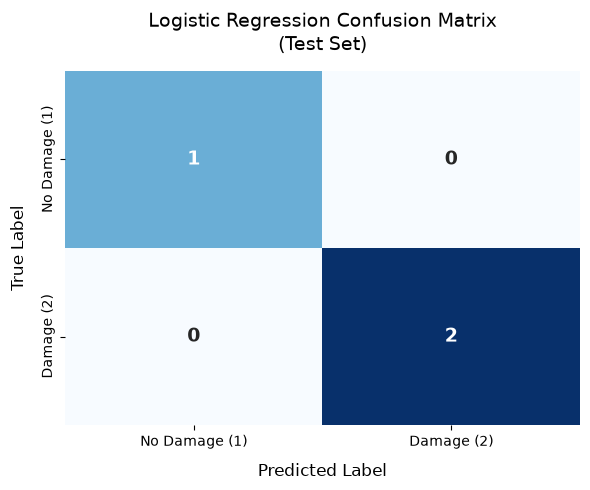

Confusion Matrix Text Output:
[[1 0]
 [0 2]]


In [30]:
# --- VISUALIZE CONFUSION MATRIX ---
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    cbar=False,
    xticklabels=["No Damage (1)", "Damage (2)"],
    yticklabels=["No Damage (1)", "Damage (2)"],
    annot_kws={"size": 14, "weight": "bold"}
)

ax.set_xlabel("Predicted Label", fontsize=12, labelpad=10)
ax.set_ylabel("True Label", fontsize=12, labelpad=10)
ax.set_title("Logistic Regression Confusion Matrix\n(Test Set)", fontsize=14, pad=15)

plt.tight_layout()
plt.savefig("logistic_regression_confusion_matrix.png", dpi=150)
plt.show()

# Print text backup to terminal
print("Confusion Matrix Text Output:")
print(cm)